# 🇰🇪 Alternative Credit Scoring Model for Unbanked Kenyans

## About This Project

In Kenya, millions of hardworking people are locked out of formal credit
despite being financially active. Boda boda riders, mama mbogas, hawkers,
jua kali artisans and casual labourers transact daily through mobile money
yet traditional banks cannot score them because they lack payslips,
collateral or a formal credit history.

This project builds an Alternative Credit Scoring Model that uses
mobile money behaviour and other alternative data points to predict
credit risk for unbanked Kenyans — giving financial institutions like
Absa Bank Kenya, Equity Bank, KCB and digital lenders like Tala and
Branch a data-driven way to safely extend credit to this underserved market.

---

## The Problem

Traditional credit scoring models rely on:
- Formal employment payslips
- Bank statements
- Collateral and assets
- Credit bureau history

This automatically excludes the majority of Kenyans who work in the
informal sector — yet these individuals are often highly reliable
financial actors who save, transact and repay consistently through
mobile money platforms like M-Pesa and Airtel Money.

---

## The Solution

By leveraging **alternative data** we can build a fairer, more
inclusive credit scoring system. This model uses:

- Mobile money transaction frequency
- Mobile money savings behaviour
- Monthly income estimates
- Smartphone ownership
- Prior loan repayment history
- Years in business
- Location — urban vs rural

---

## Project Goals

✅ Build a realistic dataset of 2,000 unbanked Kenyan applicants  
✅ Train and compare machine learning models to predict credit risk  
✅ Identify the strongest predictors of creditworthiness  
✅ Segment applicants into actionable risk tiers for loan officers  
✅ Deploy an interactive dashboard for real-time credit assessment  

---

## Project Objectives

1. Generate a synthetic dataset simulating real Kenyan informal sector workers
2. Clean and prepare the data for machine learning
3. Train a Logistic Regression baseline model and a Random Forest model
4. Evaluate model performance using accuracy, precision and recall
5. Visualize feature importance to understand what drives credit risk
6. Assign applicants to risk tiers — Low Risk, Medium Risk and High Risk
7. Deploy a live Streamlit dashboard for interactive credit scoring

---

## Target Users

| User | How They Use This |
|---|---|
| **Bank Credit Officers** | Assess loan applications from informal sector workers |
| **Digital Lenders** | Automate credit decisions for mobile lending products |
| **Microfinance Institutions** | Identify low risk borrowers in underserved communities |
| **CBK & Regulators** | Understand financial inclusion gaps across counties |

---

## Built By
**Ashley Nyaboke Kibwogo**  
Junior Data Scientist | Nairobi, Kenya  
🔗 [LinkedIn](https://www.linkedin.com/in/ashley-nyaboke/)  
💻 [GitHub](https://github.com/AshleyNyaboke)

In [1]:
#Importing the neccesary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# Building the dataset

np.random.seed(42)
n = 2000

# These are the types of unbanked Kenyans

occupations = [
    "Boda Boda Rider", "Mama Mboga", "Hawker",
    "Jua Kali Artisan", "Content Creator",
    "Casual Labourer", "Fish Monger",
    "Salon/Barber", "Matatu Operator", "Farmer"
]

counties = [
    "Nairobi", "Mombasa", "Kisumu", "Nakuru",
    "Eldoret", "Kiambu", "Machakos", "Meru",
    "Nyeri", "Kakamega", "Kisii", "Kilifi",
    "Garissa", "Kitui", "Bungoma", "Uasin Gishu",
    "Muranga", "Embu", "Kericho", "Migori"
]
county_weights = [
    0.20,0.08,0.07,0.07,0.06,0.06,0.05,
    0.04,0.04,0.04,0.04,0.03,0.03,0.03,
    0.03,0.03,0.03,0.02,0.02,0.02
]
county_weights = [w/sum(county_weights) for w in county_weights]

# Build our dataset of 2000 unbanked Kenyans
df = pd.DataFrame({
    "county": np.random.choice(counties, n, p=county_weights),
    "occupation": np.random.choice(occupations, n),
    "age": np.random.randint(18, 55, n),
    "monthly_income_ksh": np.random.choice(
        [5000, 10000, 15000, 25000, 40000, 60000],
        n, p=[0.20, 0.25, 0.25, 0.15, 0.10, 0.05]
    ),
    "mobile_money_freq_per_month": np.random.randint(0, 60, n),
    "mobile_money_savings_ksh": np.random.choice(
        [0, 500, 1000, 3000, 5000, 10000],
        n, p=[0.25, 0.20, 0.20, 0.15, 0.12, 0.08]
    ),
    "owns_smartphone": np.random.choice([0, 1], n, p=[0.40, 0.60]),
    "years_in_business": np.random.randint(0, 15, n),
    "has_prior_loan": np.random.choice([0, 1], n, p=[0.65, 0.35]),
    "repaid_prior_loan": np.random.choice([0, 1], n, p=[0.30, 0.70]),
    "urban": np.random.choice([0, 1], n, p=[0.38, 0.62]),
})


In [5]:
df.shape

(2000, 11)

In [6]:
df.head()

,county,occupation,age,monthly_income_ksh,mobile_money_freq_per_month,mobile_money_savings_ksh,owns_smartphone,years_in_business,has_prior_loan,repaid_prior_loan,urban
0,Nakuru,Fish Monger,49,40000,21,1000,0,14,1,1,0
1,Embu,Hawker,25,15000,54,0,1,11,0,1,1
2,Kisii,Fish Monger,25,15000,57,1000,1,7,1,1,1
3,Meru,Salon/Barber,23,10000,55,500,0,7,0,0,1
4,Nairobi,Farmer,31,15000,27,500,1,1,0,0,1


In [7]:
# Creating the target variable
# We create a credit score based on what we know about each person from their mobile money behaviour,this simulates how a real alternative credit
# scoring model would work

credit_score = (
    0.30 * (df["mobile_money_freq_per_month"] / 60) +
    0.25 * (df["monthly_income_ksh"] / 60000) +
    0.20 * df["repaid_prior_loan"] * df["has_prior_loan"] +
    0.15 * (df["mobile_money_savings_ksh"] / 10000) +
    0.10 * df["owns_smartphone"]
)

# Adding some noise to make it realistic
noise = np.random.normal(0, 0.08, n)
credit_prob = (credit_score + noise).clip(0, 1)

# 1 = Low Risk (good candidate for loan)
# 0 = High Risk (likely to default)
df["low_risk"] = (credit_prob > 0.45).astype(int)

print("Low risk applicants:", df["low_risk"].sum())
print("High risk applicants:", (df["low_risk"] == 0).sum())
print("\nLow risk rate:", df["low_risk"].mean().round(2))


Low risk applicants: 611
High risk applicants: 1389

Low risk rate: 0.31


In [8]:
# Explore the Data
df['occupation'].value_counts()

,count
occupation,
Casual Labourer,216
Hawker,211
Salon/Barber,211
Boda Boda Rider,210
Matatu Operator,203
Content Creator,197
Jua Kali Artisan,195
Fish Monger,188
Mama Mboga,185


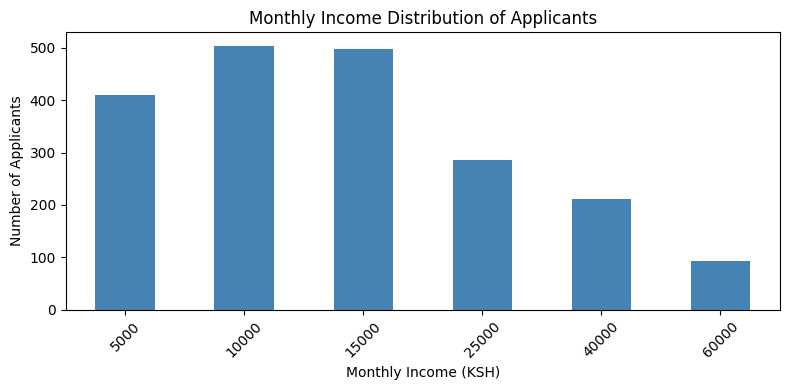

In [9]:
# The income distribution
plt.figure(figsize=(8, 4))
df["monthly_income_ksh"].value_counts().sort_index().plot(kind="bar", color="steelblue")
plt.title("Monthly Income Distribution of Applicants")
plt.xlabel("Monthly Income (KSH)")
plt.ylabel("Number of Applicants")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
# Preparing Data for the Model
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [12]:
# Convert text columns to numbers
df_model = df.copy()
le = LabelEncoder()
df_model["county"] = le.fit_transform(df_model["county"])
df_model["occupation"] = le.fit_transform(df_model["occupation"])


In [13]:
# X = the features we give the model (the clues)
# y = what we want to predict (low risk or not)
X = df_model.drop("low_risk", axis=1)
y = df_model["low_risk"]


In [17]:
# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
len(X_train)

1600

In [19]:
len(X_test)

400

In [20]:
# Training the models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [21]:
# Model 1: Logistic Regression (our baseline)
lr = LogisticRegression(max_iter=5000, solver='saga')
lr.fit(X_train, y_train)
lr_acc = accuracy_score(y_test, lr.predict(X_test))
print(f"Logistic Regression Accuracy: {lr_acc:.2%}")

Logistic Regression Accuracy: 72.25%


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [23]:
# Model 2: Random Forest (our main model)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_acc = accuracy_score(y_test, rf.predict(X_test))
print(f"Random Forest Accuracy:       {rf_acc:.2%}")

Random Forest Accuracy:       84.50%


In [24]:
# Detailed report
print("\n--- Random Forest Detailed Report ---")
print(classification_report(y_test, rf.predict(X_test)))


--- Random Forest Detailed Report ---
              precision    recall  f1-score   support

           0       0.86      0.94      0.89       282
           1       0.80      0.63      0.70       118

    accuracy                           0.84       400
   macro avg       0.83      0.78      0.80       400
weighted avg       0.84      0.84      0.84       400



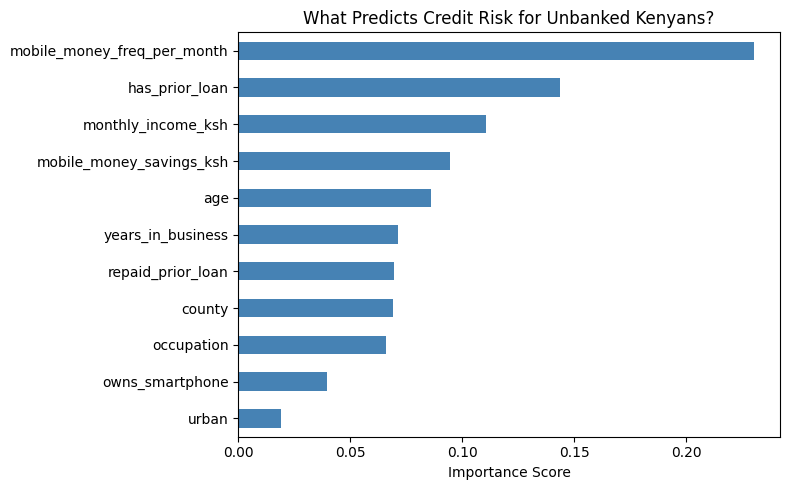

In [25]:
# Feature Importance Chart
# Which features does the model find most useful
# for predicting credit risk?

feat_imp = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
feat_imp.plot(kind="barh", color="steelblue")
plt.title("What Predicts Credit Risk for Unbanked Kenyans?")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

Risk Tier Breakdown:
High Risk — Reject       277
Medium Risk — Review      68
Low Risk — Fast Track     55
Name: count, dtype: int64


<Figure size 700x400 with 0 Axes>

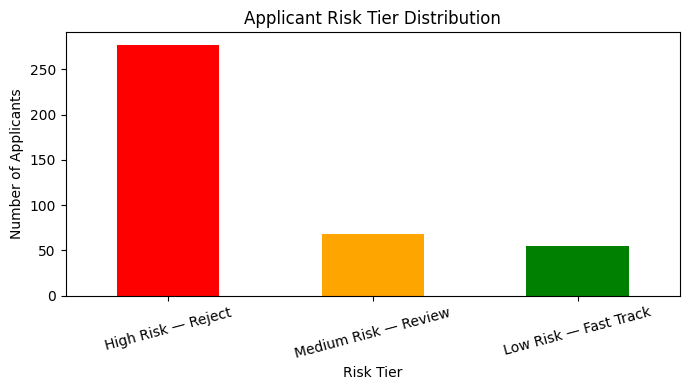

In [29]:
# Rist Tier Breakdown
# Assign each applicant to a risk tier

rf_probs = rf.predict_proba(X_test)[:, 1]

tiers = []
for prob in rf_probs:
    if prob >= 0.65:
        tiers.append("Low Risk — Fast Track")
    elif prob >= 0.40:
        tiers.append("Medium Risk — Review")
    else:
        tiers.append("High Risk — Reject")

tier_counts = pd.Series(tiers).value_counts()
print("Risk Tier Breakdown:")
print(tier_counts)

# Visualize
plt.figure(figsize=(7, 4))
colors = {
    "Low Risk — Fast Track": "green",
    "Medium Risk — Review": "orange",
    "High Risk — Reject": "red"
}
bar_colors = [colors[tier] for tier in tier_counts.index]

plt.figure(figsize=(7, 4))
tier_counts.plot(kind="bar", color=bar_colors)
plt.title("Applicant Risk Tier Distribution")
plt.xlabel("Risk Tier")
plt.ylabel("Number of Applicants")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [30]:
# Install Streamlit
!pip install streamlit pyngrok -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 34.5 MB/s eta 0:00:00


In [31]:
app_code = """import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

st.set_page_config(
    page_title="Unbanked Kenya Credit Scorer",
    page_icon="🤝",
    layout="wide"
)

# Custom CSS for warm card based layout
st.markdown(\"\"\"
<style>
    .main { background-color: #FFF8F0; }
    .card {
        background-color: white;
        padding: 20px;
        border-radius: 12px;
        border-left: 5px solid #E07B2A;
        margin-bottom: 16px;
        box-shadow: 2px 2px 8px rgba(0,0,0,0.07);
    }
    .green-card {
        background-color: white;
        padding: 20px;
        border-radius: 12px;
        border-left: 5px solid #2E7D32;
        margin-bottom: 16px;
        box-shadow: 2px 2px 8px rgba(0,0,0,0.07);
    }
    .metric-box {
        background-color: #FFF3E0;
        padding: 16px;
        border-radius: 10px;
        text-align: center;
        margin-bottom: 12px;
    }
    .big-number {
        font-size: 48px;
        font-weight: bold;
        color: #E07B2A;
    }
    .section-title {
        color: #E07B2A;
        font-size: 20px;
        font-weight: bold;
        margin-bottom: 8px;
    }
    div[data-testid="stButton"] button {
        background-color: #E07B2A;
        color: white;
        border-radius: 8px;
        width: 100%;
        font-size: 16px;
        padding: 10px;
        border: none;
    }
</style>
\"\"\", unsafe_allow_html=True)

# Header
st.markdown(\"\"\"
<div style='background: linear-gradient(135deg, #E07B2A, #2E7D32);
     padding: 30px; border-radius: 16px; margin-bottom: 24px;'>
    <h1 style='color: white; margin:0;'>🤝 Credit For All Kenyans</h1>
    <p style='color: #FFE0B2; font-size: 16px; margin-top: 8px;'>
    Predicting credit risk for boda boda riders, mama mbogas, hawkers
    and jua kali artisans — using mobile money behaviour, not payslips.
    </p>
</div>
\"\"\", unsafe_allow_html=True)

@st.cache_resource
def train_model():
    np.random.seed(42)
    n = 2000
    occupations = [
        "Boda Boda Rider", "Mama Mboga", "Hawker",
        "Jua Kali Artisan", "Content Creator",
        "Casual Labourer", "Fish Monger",
        "Salon/Barber", "Matatu Operator", "Farmer"
    ]
    counties = [
        "Nairobi", "Mombasa", "Kisumu", "Nakuru",
        "Eldoret", "Kiambu", "Machakos", "Meru",
        "Nyeri", "Kakamega", "Kisii", "Kilifi",
        "Garissa", "Kitui", "Bungoma", "Uasin Gishu",
        "Muranga", "Embu", "Kericho", "Migori"
    ]
    county_weights = [
        0.20,0.08,0.07,0.07,0.06,0.06,0.05,
        0.04,0.04,0.04,0.04,0.03,0.03,0.03,
        0.03,0.03,0.03,0.02,0.02,0.02
    ]
    county_weights = [w/sum(county_weights) for w in county_weights]

    df = pd.DataFrame({
        "county": np.random.choice(counties, n, p=county_weights),
        "occupation": np.random.choice(occupations, n),
        "age": np.random.randint(18, 55, n),
        "monthly_income_ksh": np.random.choice(
            [5000, 10000, 15000, 25000, 40000, 60000],
            n, p=[0.20, 0.25, 0.25, 0.15, 0.10, 0.05]
        ),
        "mobile_money_freq_per_month": np.random.randint(0, 60, n),
        "mobile_money_savings_ksh": np.random.choice(
            [0, 500, 1000, 3000, 5000, 10000],
            n, p=[0.25, 0.20, 0.20, 0.15, 0.12, 0.08]
        ),
        "owns_smartphone": np.random.choice([0, 1], n, p=[0.40, 0.60]),
        "years_in_business": np.random.randint(0, 15, n),
        "has_prior_loan": np.random.choice([0, 1], n, p=[0.65, 0.35]),
        "repaid_prior_loan": np.random.choice([0, 1], n, p=[0.30, 0.70]),
        "urban": np.random.choice([0, 1], n, p=[0.38, 0.62]),
    })

    credit_score = (
        0.30 * (df["mobile_money_freq_per_month"] / 60) +
        0.25 * (df["monthly_income_ksh"] / 60000) +
        0.20 * df["repaid_prior_loan"] * df["has_prior_loan"] +
        0.15 * (df["mobile_money_savings_ksh"] / 10000) +
        0.10 * df["owns_smartphone"]
    )
    noise = np.random.normal(0, 0.08, n)
    df["low_risk"] = ((credit_score + noise).clip(0, 1) > 0.45).astype(int)

    le_county = LabelEncoder()
    le_occ = LabelEncoder()
    df["county_enc"] = le_county.fit_transform(df["county"])
    df["occupation_enc"] = le_occ.fit_transform(df["occupation"])

    features = ["county_enc", "occupation_enc", "age",
                "monthly_income_ksh", "mobile_money_freq_per_month",
                "mobile_money_savings_ksh", "owns_smartphone",
                "years_in_business", "has_prior_loan",
                "repaid_prior_loan", "urban"]

    X = df[features]
    y = df["low_risk"]

    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X, y)
    return rf, le_county, le_occ, df, features

rf, le_county, le_occ, df, features = train_model()

# Portfolio stats row
st.markdown("<p class='section-title'>📊 Portfolio Overview</p>",
            unsafe_allow_html=True)

total = len(df)
low = df["low_risk"].sum()
high = total - low
low_pct = round((low/total)*100)

c1, c2, c3, c4 = st.columns(4)
with c1:
    st.markdown(f\"\"\"<div class='metric-box'>
        <div style='color:#777;font-size:13px'>Total Applicants</div>
        <div class='big-number'>{total:,}</div>
    </div>\"\"\", unsafe_allow_html=True)
with c2:
    st.markdown(f\"\"\"<div class='metric-box'>
        <div style='color:#777;font-size:13px'>Low Risk</div>
        <div class='big-number' style='color:#2E7D32'>{low:,}</div>
    </div>\"\"\", unsafe_allow_html=True)
with c3:
    st.markdown(f\"\"\"<div class='metric-box'>
        <div style='color:#777;font-size:13px'>High Risk</div>
        <div class='big-number' style='color:#C62828'>{high:,}</div>
    </div>\"\"\", unsafe_allow_html=True)
with c4:
    st.markdown(f\"\"\"<div class='metric-box'>
        <div style='color:#777;font-size:13px'>Approval Rate</div>
        <div class='big-number'>{low_pct}%</div>
    </div>\"\"\", unsafe_allow_html=True)

st.markdown("<br>", unsafe_allow_html=True)

# Two column layout
left, right = st.columns([1, 1])

with left:
    st.markdown(\"\"\"<div class='card'>
        <p class='section-title'>📋 Applicant Profile</p>
    </div>\"\"\", unsafe_allow_html=True)

    county = st.selectbox("County", sorted([
        "Nairobi", "Mombasa", "Kisumu", "Nakuru",
        "Eldoret", "Kiambu", "Machakos", "Meru",
        "Nyeri", "Kakamega", "Kisii", "Kilifi",
        "Garissa", "Kitui", "Bungoma", "Uasin Gishu",
        "Muranga", "Embu", "Kericho", "Migori"
    ]))
    occupation = st.selectbox("Occupation", [
        "Boda Boda Rider", "Mama Mboga", "Hawker",
        "Jua Kali Artisan", "Content Creator",
        "Casual Labourer", "Fish Monger",
        "Salon/Barber", "Matatu Operator", "Farmer"
    ])
    age = st.slider("Age", 18, 55, 28)
    income = st.selectbox("Monthly Income (KSH)",
        [5000, 10000, 15000, 25000, 40000, 60000], index=2)
    mm_freq = st.slider("Mobile Money Transactions per Month", 0, 60, 20)
    mm_savings = st.selectbox("Mobile Money Savings (KSH)",
        [0, 500, 1000, 3000, 5000, 10000], index=2)
    smartphone = st.radio("Owns Smartphone?", ["Yes", "No"])
    years_biz = st.slider("Years in Business", 0, 15, 3)
    prior_loan = st.radio("Has Prior Loan?", ["Yes", "No"])
    repaid = st.radio("Repaid Prior Loan?", ["Yes", "No"])
    location = st.radio("Location", ["Urban", "Rural"])
    predict_btn = st.button("🔍 Assess Credit Risk")

with right:
    st.markdown(\"\"\"<div class='green-card'>
        <p class='section-title' style='color:#2E7D32'>
        🎯 Credit Risk Result</p>
    </div>\"\"\", unsafe_allow_html=True)

    if predict_btn:
        county_enc = le_county.transform([county])[0]
        occ_enc = le_occ.transform([occupation])[0]

        input_data = pd.DataFrame([{
            "county_enc": county_enc,
            "occupation_enc": occ_enc,
            "age": age,
            "monthly_income_ksh": income,
            "mobile_money_freq_per_month": mm_freq,
            "mobile_money_savings_ksh": mm_savings,
            "owns_smartphone": 1 if smartphone == "Yes" else 0,
            "years_in_business": years_biz,
            "has_prior_loan": 1 if prior_loan == "Yes" else 0,
            "repaid_prior_loan": 1 if repaid == "Yes" else 0,
            "urban": 1 if location == "Urban" else 0
        }])

        prob = rf.predict_proba(input_data)[0][1]

        st.markdown(f\"\"\"<div class='metric-box' style='margin-top:20px'>
            <div style='color:#777;font-size:14px'>
            Low Risk Probability</div>
            <div class='big-number'>{prob:.0%}</div>
        </div>\"\"\", unsafe_allow_html=True)

        if prob >= 0.65:
            st.success("✅ LOW RISK — Fast Track for loan approval!")
            st.markdown(\"\"\"<div class='green-card'>
                <b>Recommendation:</b> This applicant shows strong
                mobile money behaviour and repayment history.
                Eligible for automated mobile disbursement.
            </div>\"\"\", unsafe_allow_html=True)
        elif prob >= 0.40:
            st.warning("⚠️ MEDIUM RISK — Manual review recommended")
            st.markdown(\"\"\"<div class='card'>
                <b>Recommendation:</b> This applicant shows moderate
                creditworthiness. A loan officer should review further
                before approval.
            </div>\"\"\", unsafe_allow_html=True)
        else:
            st.error("❌ HIGH RISK — Loan not recommended at this time")
            st.markdown(\"\"\"<div style='background:#FFF3F3;padding:16px;
                border-radius:10px;border-left:5px solid #C62828'>
                <b>Recommendation:</b> Insufficient mobile money
                activity or prior default history. Consider financial
                literacy support first.
            </div>\"\"\", unsafe_allow_html=True)

        st.progress(float(prob))
        st.divider()

        st.markdown("<p class='section-title'>📊 Key Risk Drivers</p>",
                    unsafe_allow_html=True)
        feat_imp = pd.Series(
            rf.feature_importances_,
            index=["County","Occupation","Age","Income",
                   "MM Frequency","MM Savings","Smartphone",
                   "Years in Biz","Prior Loan",
                   "Repaid Loan","Urban"]
        ).sort_values(ascending=True)

        fig, ax = plt.subplots(figsize=(6, 4))
        colors = ["#2E7D32" if v > feat_imp.median()
                  else "#E07B2A" for v in feat_imp.values]
        feat_imp.plot(kind="barh", ax=ax, color=colors)
        ax.set_title("What Drives This Credit Decision?")
        ax.set_xlabel("Importance Score")
        plt.tight_layout()
        st.pyplot(fig)

    else:
        st.markdown(\"\"\"<div style='text-align:center;
            padding:60px 20px;color:#999;'>
            <h3>👈 Fill in the applicant profile</h3>
            <p>and click Assess Credit Risk to see the result</p>
        </div>\"\"\", unsafe_allow_html=True)

st.divider()

# County insights
st.markdown("<p class='section-title'>📍 Low Risk Rate by County</p>",
            unsafe_allow_html=True)
st.markdown(\"\"\"<div class='card'>
Which counties have the highest concentration of creditworthy
unbanked applicants?
</div>\"\"\", unsafe_allow_html=True)

county_risk = df.groupby("county")["low_risk"].mean().sort_values(
    ascending=False)
fig2, ax2 = plt.subplots(figsize=(12, 4))
county_risk.plot(kind="bar", ax=ax2, color="#E07B2A")
ax2.set_title("Low Risk Rate by County")
ax2.set_ylabel("Low Risk Rate")
ax2.set_xlabel("County")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
st.pyplot(fig2)

st.divider()

# Occupation breakdown
st.markdown("<p class='section-title'>💼 Risk by Occupation</p>",
            unsafe_allow_html=True)
occ_risk = df.groupby("occupation")["low_risk"].mean().sort_values(
    ascending=False)
fig3, ax3 = plt.subplots(figsize=(10, 4))
occ_risk.plot(kind="bar", ax=ax3, color="#2E7D32")
ax3.set_title("Low Risk Rate by Occupation")
ax3.set_ylabel("Low Risk Rate")
ax3.set_xlabel("Occupation")
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
st.pyplot(fig3)

st.caption(\"\"\"Built by Ashley Nyaboke Kibwogo |
Alternative Credit Scoring for Unbanked Kenyans |
🇰🇪 Financial Inclusion Project\"\"\")
"""

with open("credit_app.py", "w") as f:
    f.write(app_code)

import py_compile
try:
    py_compile.compile("credit_app.py", doraise=True)
    print("✅ credit_app.py written cleanly!")
except py_compile.PyCompileError as e:
    print(f"❌ Syntax error: {e}")

✅ credit_app.py written cleanly!


In [33]:
import subprocess
import threading
import time
from pyngrok import ngrok

# Paste your NEW ngrok token here
NGROK_TOKEN = "3DLYec2eRFRvaiu0DnWXSIejvPA_7gx9C6byi2JSzX5m7wcsn"

ngrok.set_auth_token(NGROK_TOKEN)
ngrok.kill()
time.sleep(2)

def run_streamlit():
    subprocess.run(["streamlit", "run", "credit_app.py",
                   "--server.port", "8502",
                   "--server.headless", "true"])

thread = threading.Thread(target=run_streamlit)
thread.daemon = True
thread.start()

time.sleep(5)

public_url = ngrok.connect(8502)
print(f"\n🚀 Your dashboard is LIVE at: {public_url}")
print("\nShare this link with anyone! 🇰🇪")


🚀 Your dashboard is LIVE at: NgrokTunnel: "https://styling-uncapped-flaxseed.ngrok-free.dev" -> "http://localhost:8502"

Share this link with anyone! 🇰🇪


In [34]:
from google.colab import files
files.download("credit_app.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>